# Graph-DTW matching playground

**See which points/segments of edge A match which B edges — and play with the edge.**

- Every A sample point is painted in the color of the B-edge it matched, with a link to its
  matched B point: the correspondence reads directly off the picture. No analysis panels.
- Move the sliders (**shift / rotate / noise / translate / crop / ...**) and the match re-runs
  live against the unchanged B-network.
- In the last section you can **build your own sample** — edges are plain coordinate lists;
  add a B-edge by appending one line.

Kernel: `network-matching` (needs `ipywidgets`; `pip install ipywidgets` once if missing).

In [1]:
# Setup (run once) -- the code lives in network_matching/playground.py; %autoreload picks up
# library changes without restarting, and the printed version shows which code this kernel runs.
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt

from network_matching import match_edge_to_bgraph
from network_matching.synthetic import SCENARIOS, get_scenario
from network_matching.playground import (PLAYGROUND_VERSION, draw_match, perturb_edge,
                                         playground, to_edges)

print("playground code:", PLAYGROUND_VERSION)
print(len(SCENARIOS), "built-in cases:", ", ".join(sorted(SCENARIOS)))

playground code: v4 -- midpoint links; junction/sliver pass-throughs drawn dotted gray (they are crossings, not segment matches)
8 built-in cases: curve, cycle, gap, junction_turn, overhang, parallel_trap, split, stub


## Static example (no widgets)

One call = one picture. `parallel_trap` shifted 6 m toward the parallel road — every A point
shows which B-edge it ended up matched to.

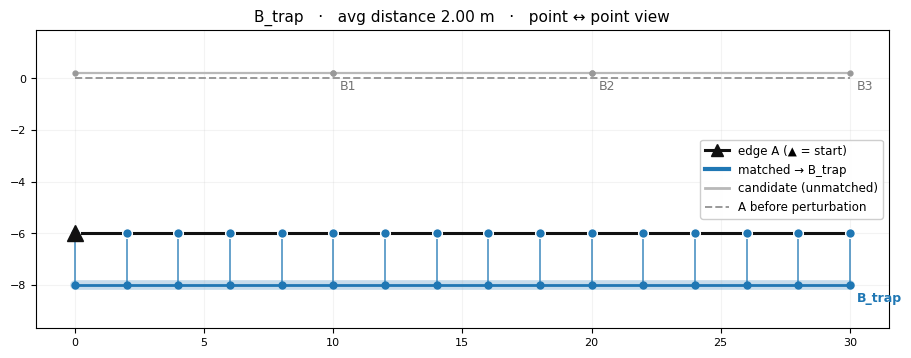

In [2]:
sc = get_scenario("parallel_trap")
A = perturb_edge(sc["coords_a"], shift=-6)

# every algorithm parameter, spelled out (the values shown are the LIBRARY defaults,
# except step_meters/snap, where the small synthetic cases use 2.0 / 0.5):
res = match_edge_to_bgraph(
    A.tolist(), sc["b_edges"],
    emission="point",        # local cost: "point" (point-to-point, default) or "segment"
    bearing_weight=0.0,      # lambda: heading penalty, SEGMENT MODE ONLY (0 = off, default)
    step_meters=2.0,         # gap-fill spacing: pools get extra points so no gap exceeds
                             #   this many meters (library default 10.0; falsy = no fill)
    snap_tolerance_m=0.5,    # B connectivity: end->start junction snap (library default 0.75)
    trim_ends_m=0.0,         # optional end-fragment cleanup (default 0 = off)
)
draw_match(A, sc["b_edges"], res, original_a=sc["coords_a"])
plt.show()

## Static example — segment-to-segment

With `emission="segment"` the DP matches **(A-segment, B-segment)** pairs, and the plot draws
one link per matched pair, running **from the middle of the A-segment to the middle of its
matched B-segment** (pass `debug=True` — the segment states come from the debug payload).
With `emission="point"` the links connect the matched points themselves, which is what that
cost model actually matches.

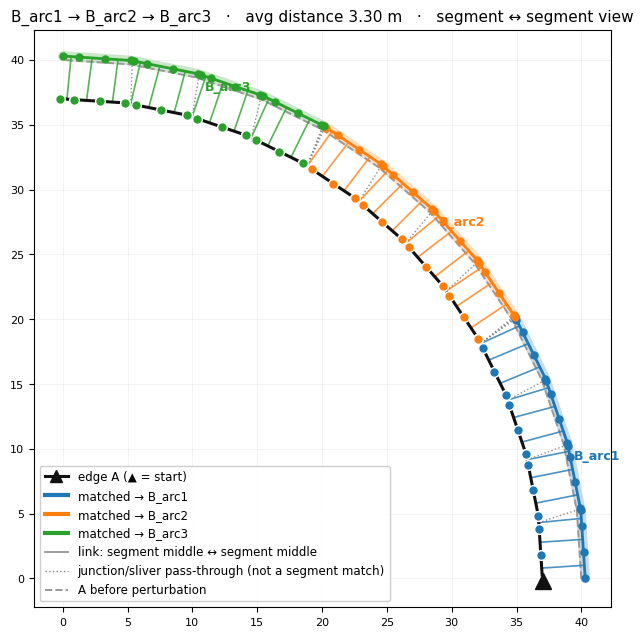

In [3]:
sc = get_scenario("curve")
A = perturb_edge(sc["coords_a"], shift=3)
res = match_edge_to_bgraph(A.tolist(), sc["b_edges"], emission="segment", debug=True,
                           **sc["defaults"])
draw_match(A, sc["b_edges"], res, original_a=sc["coords_a"])
plt.show()

## Interactive playground — built-in cases

Pick a case, drag the sliders, watch the correspondence change (sliders update on release).
The same sliders work on your own network in the last section.

### How the edge can be changed (slider → keyword → meaning)

Only **edge A moves** — the B-network never changes. In code, the same names are keywords of
`perturb_edge(...)` (and flags of the CLI scripts).

| Slider | Keyword | Unit | What it does |
|---|---|---|---|
| `shift m` | `shift` | m | Move **perpendicular to the road's own direction** (follows curves). + = left of travel, − = right. On a horizontal left→right edge that means: **+ = up, − = down.** |
| `along m` | `longitudinal` | m | Slide **lengthwise along the road** (a lengthwise misregistration). DTW can absorb much of it by re-warping. |
| `translate m` + `direction °` | `translate`, `translate_bearing` | m, ° | Rigid move in a **fixed compass direction**, independent of the edge's shape: **0 = up/north, 90 = right/east, 180 = down/south, 270 = left/west** (any angle works). Use this for guaranteed up/down on any edge. |
| `rotate °` | `rotate` | ° | Rotate the whole edge about its centroid (a bearing/registration error). |
| `noise σ` + `noise seed` | `noise`, `seed` | m | Gaussian jitter of every vertex. The edge is densified to 5 m spacing first, so even a 2-point edge gets a genuinely wiggly shape; `seed` picks the random pattern. |
| `crop %` | `crop` | % | Shorten: remove this % of total length, **half from each end** (a partial edge). |
| `stretch m` | `stretch` | m | Extend **both ends outward** along the end tangents (overhang past the B corridor). |
| `reverse direction` | `reverse_dir` | — | Flip the digitized direction. B is a **directed** table, so this should degrade to NO_MATCH unless a reverse twin edge exists. |

When several are set they compose in a fixed order — crop → stretch → rotate → translate →
shift → along → noise (→ reverse) — so slider settings and scripted `perturb_edge(...)` calls
give identical results.

In [4]:
playground()

Output()

## Build your own sample — add edges

A network is just coordinate lists (meters, any local frame). **B is directed**: each edge is
walked in the order you type its points, and edges connect where one edge's *end* touches
another edge's *start* (within the snap tolerance). Add a B-edge by appending one
`("id", [(x, y), (x, y), ...])` line — then re-run the cell.

In [5]:
my_a = [(0, 1), (25, 1), (45, 12)]            # the edge to match (drawn black)

my_b_edges = [
    ("main_1",  [(0, 0), (12, 0)]),           # chain along A...
    ("main_2",  [(12, 0), (25, 0)]),
    ("ramp",    [(25, 0), (45, 11)]),         # ...bending off with A
    ("straight", [(25, 0), (45, 0)]),         # competing straight continuation
    ("side",    [(12, -9), (12, 0)]),         # side road digitized INTO the junction
    # ("new_edge", [(45, 11), (60, 18)]),     # <- add your next edge like this
]

playground(my_a, my_b_edges)

Output()

---
## Algorithm parameters (slider → keyword → default)

| Slider | Keyword | Default | Meaning |
|---|---|---|---|
| `emission` | `emission` | `"point"` | local cost model: `point` = point-to-point distance; `segment` = direction-aware endpoint-average of the traversed A-/B-segments |
| `bearing λ` | `bearing_weight` | `0.0` (off) | heading penalty λ · circular bearing difference (degrees), **segment mode only** — point mode ignores it. λ=0.1 means a 10° heading error costs like 1 m of drift |
| `sample m` | `step_meters` | `10.0` (cases here use `2.0`) | the "extra points": each edge's point pool = its own vertices + projections of the other side's vertices + gap-fill points so no gap exceeds this many meters. Smaller = denser = more points (and slower); set falsy in code to disable gap-fill |
| `snap tol` | `snap_tolerance_m` | `0.75` (cases here use `0.5`) | B-network connectivity: one edge's END joins another's START if they are within this distance — raise it to bridge the `gap` case, lower it to break chains apart |
| — | `trim_ends_m` | `0.0` (off) | optional cleanup that drops a leading/trailing route edge covering less than this many meters of A |

Try: case `split`, emission `segment`, rotate ~20° — then raise `bearing λ` from 0 to 0.5 and
watch the heading term start to matter. Or case `gap`: slide `snap tol` past 2.0 and the two
halves connect.

Deeper looks, when you want them: `scripts/graph_dtw_debug_viz.py` renders the DP internals for
any of these cases, `scripts/graph_dtw_perturb_test.py` sweeps whole perturbation families —
see `docs/graph_dtw_debugging.md`.

## Proof cell — point↔point vs segment↔segment, side by side

Same edge, same network, matched twice: left with `emission="point"` (links between matched
POINTS), right with `emission="segment"` (one link per matched segment pair, drawn from the
**middle of the A-segment to the middle of the matched B-segment**).

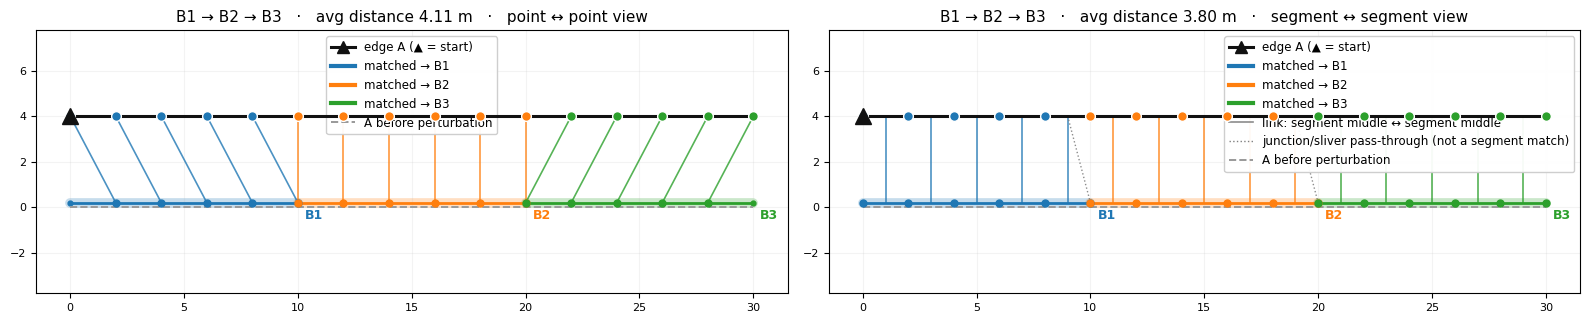

In [6]:
sc = get_scenario("split")
A = perturb_edge(sc["coords_a"], shift=4)          # shifted 4 m so the links are visible

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, emission in zip(axes, ["point", "segment"]):
    res = match_edge_to_bgraph(A.tolist(), sc["b_edges"], emission=emission, debug=True,
                               **sc["defaults"])
    draw_match(A, sc["b_edges"], res, original_a=sc["coords_a"], ax=ax)
plt.tight_layout()
plt.show()